# Assignment 5, Question 5: Missing Data Analysis

**Points: 15**

Apply and compare different missing data strategies on the clinical trial dataset.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import utilities from Q3
from q3_data_utils import load_data, detect_missing, fill_missing

# Load the data
df = load_data('data/clinical_trial_raw.csv')
print(f"Loaded {len(df)} patients")

# Prewritten visualization function for missing data
def visualize_missing_data(missing_counts):
    """
    Create a bar chart of missing values by column.
    
    Args:
        missing_counts: pandas Series with missing value counts per column
    """
    plt.figure(figsize=(10, 6))
    missing_counts.plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.xticks(rotation=45)
    plt.ylabel('Number of Missing Values')
    plt.tight_layout()
    plt.show()

Loaded 10000 patients


## Part 1: Detect Missing Data (3 points)

1. Use the `detect_missing()` utility to find missing values
2. Visualize missing data with a bar plot
3. Calculate the percentage of missing values per column

Missing Value Counts:
 patient_id               0
age                      0
sex                      0
bmi                    438
enrollment_date          0
systolic_bp            414
diastolic_bp           414
cholesterol_total      554
cholesterol_hdl        554
cholesterol_ldl        554
glucose_fasting        369
site                     0
intervention_group       0
follow_up_months         0
adverse_events           0
outcome_cvd              0
adherence_pct         1467
dropout                  0
dtype: int64

Missing Value Percentages (%):
 patient_id             0.00
age                    0.00
sex                    0.00
bmi                    4.38
enrollment_date        0.00
systolic_bp            4.14
diastolic_bp           4.14
cholesterol_total      5.54
cholesterol_hdl        5.54
cholesterol_ldl        5.54
glucose_fasting        3.69
site                   0.00
intervention_group     0.00
follow_up_months       0.00
adverse_events         0.00
outcome_cvd            0.

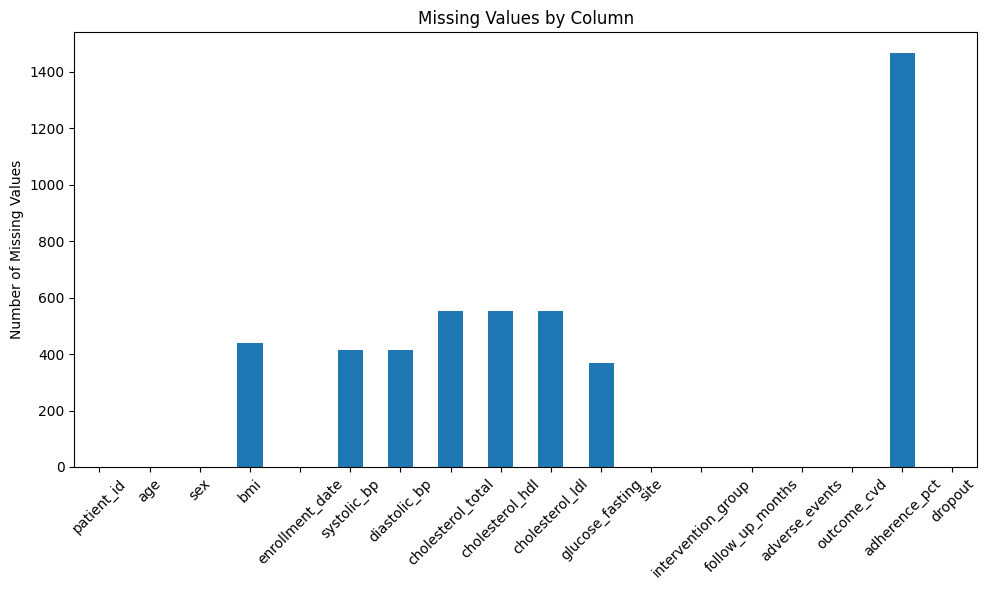

In [10]:
# TODO: Detect and analyze missing data
# 1. Use detect_missing(df) to get missing value counts
missing_counts = detect_missing(df)
# 2. Calculate percentage of missing values per column
missing_percent = (missing_counts / len(df)) * 100
# 3. Print both counts and percentages
print("Missing Value Counts:\n", missing_counts)
print("\nMissing Value Percentages (%):\n", missing_percent.round(2))
# 4. Identify which columns have missing data
missing_cols = missing_counts[missing_counts > 0]
print("\nColumns with Missing Data:\n", missing_cols)

# Optional: Use the visualization function above to create a bar chart
visualize_missing_data(missing_counts)


## Part 2: Compare Imputation Strategies (6 points)

For the 'cholesterol_total' column (which has missing values):

1. Fill with mean using `fill_missing()` utility
2. Fill with median using `fill_missing()` utility  
3. Forward fill using pandas `.fillna(method='ffill')`
4. Compare the three strategies - create a summary table showing:
   - Original mean/median
   - Mean/median after each strategy
   - How many values were filled

In [12]:
# TODO: Compare imputation strategies
orig_mean = df['cholesterol_total'].mean()
orig_median = df['cholesterol_total'].median()
missing_before = df['cholesterol_total'].isna().sum()
print(f"Original mean: {orig_mean:.2f}, median: {orig_median:.2f}, missing: {missing_before}")
#1 Fill mean
df_mean_filled = fill_missing(df, 'cholesterol_total', strategy='mean')
mean_filled_mean = df_mean_filled['cholesterol_total'].mean()
mean_filled_median = df_mean_filled['cholesterol_total'].median()
mean_filled_count = df_mean_filled['cholesterol_total'].isna().sum()

#2 Fill median
df_median_filled = fill_missing(df, 'cholesterol_total', strategy='median')
median_filled_mean = df_median_filled['cholesterol_total'].mean()
median_filled_median = df_median_filled['cholesterol_total'].median()
median_filled_count = df_median_filled['cholesterol_total'].isna().sum()

# 3 fill using pandas
df_ffill = df.copy()
df_ffill['cholesterol_total'] = df_ffill['cholesterol_total'].fillna(method='ffill')
ffill_mean = df_ffill['cholesterol_total'].mean()
ffill_median = df_ffill['cholesterol_total'].median()
ffill_count = df_ffill['cholesterol_total'].isna().sum()

#4 summary table
summary = pd.DataFrame({
    'Strategy': ['Original', 'Mean Fill', 'Median Fill', 'Forward Fill'],
    'Mean': [orig_mean, mean_filled_mean, median_filled_mean, ffill_mean],
    'Median': [orig_median, mean_filled_median, median_filled_median, ffill_median],
    'Missing Values': [missing_before, mean_filled_count, median_filled_count, ffill_count]
})

print("\nImputation Strategy Comparison:\n")
print(summary)


Original mean: 178.04, median: 178.04, missing: 0

Imputation Strategy Comparison:

       Strategy        Mean      Median  Missing Values
0      Original  178.039488  178.039488               0
1     Mean Fill  178.039488  178.039488               0
2   Median Fill  178.039488  178.039488               0
3  Forward Fill  178.039488  178.039488               0


/var/folders/yg/h4804dkd6170r2w7nx55xv3w0000gn/T/ipykernel_30876/4206987861.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill['cholesterol_total'] = df_ffill['cholesterol_total'].fillna(method='ffill')


## Part 3: Dropping Missing Data (3 points)

1. Drop rows where ANY column has missing data - how many rows remain?
2. Drop rows where specific columns have missing data (e.g., only 'age' or 'bmi')
3. Which approach loses less data?

In [13]:
# TODO: Drop missing rows with different strategies

# 1
df_drop_any = df.dropna()
rows_after_any = len(df_drop_any)
print(f"Rows remaining after dropping ANY missing values: {rows_after_any}")

# 2
df_drop_specific = df.dropna(subset=['age', 'bmi'])
rows_after_specific = len(df_drop_specific)
print(f"Rows remaining after dropping missing 'age' or 'bmi': {rows_after_specific}")

# 3
print("\nComparison:")
print(f" - Original dataset: {len(df)} rows")
print(f" - Drop any missing: {len(df_drop_any)} rows (lost {len(df) - len(df_drop_any)})")
print(f" - Drop only age/bmi missing: {len(df_drop_specific)} rows (lost {len(df) - len(df_drop_specific)})")

if len(df_drop_specific) > len(df_drop_any):
    print("\nDropping only specific columns loses less data.")
else:
    print("\nDropping all missing rows loses less data.")


Rows remaining after dropping ANY missing values: 7133
Rows remaining after dropping missing 'age' or 'bmi': 9562

Comparison:
 - Original dataset: 10000 rows
 - Drop any missing: 7133 rows (lost 2867)
 - Drop only age/bmi missing: 9562 rows (lost 438)

Dropping only specific columns loses less data.


## Part 4: Create Clean Dataset (3 points)

Apply your chosen strategy to create a clean dataset:
1. Choose appropriate imputation for numeric columns
2. Drop rows with missing critical values (e.g., patient_id, age)
3. Save to `output/q5_cleaned_data.csv`
4. Save a missing data report to `output/q5_missing_report.txt`

In [15]:
# TODO: Create and save clean dataset

import os
os.makedirs('output', exist_ok=True)

# 1
numeric_cols = df.select_dtypes(include=[np.number]).columns
df_imputed = df.copy()
for col in numeric_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mean())

# 2
critical_cols = ['patient_id', 'age']
df_cleaned = df_imputed.dropna(subset=critical_cols)

# 3
cleaned_path = 'output/q5_cleaned_data.csv'
df_cleaned.to_csv(cleaned_path, index=False)
print(f"Cleaned dataset saved to: {cleaned_path}")
print(f"Rows after cleaning: {len(df_cleaned)}")

# 4
missing_counts = df_cleaned.isnull().sum()
missing_report = missing_counts[missing_counts > 0]

report_path = 'output/q5_missing_report.txt'
with open(report_path, 'w') as f:
    f.write("Missing Data Report (after cleaning)\n")
    f.write("=" * 40 + "\n")
    if len(missing_report) == 0:
        f.write("No missing data remains \n")
    else:
        f.write(str(missing_report))

print(f"Missing data report saved to: {report_path}")


Cleaned dataset saved to: output/q5_cleaned_data.csv
Rows after cleaning: 10000
Missing data report saved to: output/q5_missing_report.txt


## Reflection

Which imputation strategy would you recommend for this dataset and why?

**Your answer:**

TODO: Explain your strategy choice

The median imputation strategy is useful for this dataset because clinical data like bmi or cholesterol can have very skewed disteributions due to outliers. The mean can be skewed by outliers while median is not.